# 🌍 Global FinTech AML Fraud Detection System
### *Production-Grade Anti-Money Laundering Intelligence Platform*

---

```
Author      : [Your Name]
Dataset     : PaySim Synthetic Mobile Money Transactions (Kaggle)
Stack       : Python · XGBoost · RandomForest · SHAP · NetworkX · Streamlit
```

---

## 🏦 Executive Summary

Money laundering costs the global economy an estimated **USD 800 billion to USD 2 trillion annually** — roughly 2–5% of global GDP (UNODC, 2022). Financial institutions worldwide face mounting pressure from regulators to deploy intelligent, explainable AML systems that go beyond static rule engines.

This project builds a **complete, production-ready AML fraud detection pipeline** that:

- Detects fraudulent transactions with **>95% ROC-AUC** using ensemble ML
- Provides **SHAP-based explanations** satisfying global explainability mandates
- Uncovers **money mule networks** via graph analysis (NetworkX)
- Delivers a **Streamlit compliance dashboard** for risk officers

---

## 📐 Business Problem Statement

> *"Design and implement an automated transaction monitoring system capable of identifying money laundering activity across millions of daily mobile payment transactions, with explainable predictions that meet global regulatory reporting standards."*

### The Three Stages of Money Laundering We Target

| Stage | Definition | PaySim Signal |
|-------|-----------|---------------|
| **Placement** | Introducing illicit cash into the financial system | Large CASH-IN from unknown sources |
| **Layering** | Disguising the trail through multiple transfers | TRANSFER chains across accounts |
| **Integration** | Withdrawing cleaned funds | CASH-OUT after layering complete |

### Why Traditional Rule Engines Fail

Most banks rely on threshold-based rules (e.g. *"flag transfers > $10,000"*). These fail because:
- **Structuring / Smurfing** — breaking large amounts into smaller transfers below thresholds
- **High false positive rates** — 95%+ of flagged transactions are legitimate, overwhelming compliance teams
- **Zero adaptability** — rules cannot learn new laundering typologies
- **No network awareness** — rules evaluate transactions in isolation, missing mule chains

### Global Regulatory Stakes

| Regulator | Region | Key Requirement | Penalty for Failure |
|-----------|--------|----------------|--------------------|
| **FinCEN** | USA | SAR filing within 30 days | Up to USD 1M per violation |
| **FCA** | UK | SYSC 6.3 transaction monitoring | Unlimited fines + licence revocation |
| **AUSTRAC** | Australia | AML/CTF Rule 2007 | AUD 222M (Commonwealth Bank case) |
| **FINTRAC** | Canada | PCMLTFA compliance | CAD 500K per violation |
| **FATF** | Global | 40 Recommendations | FATF blacklist — fatal for correspondent banking |

---

## 🗺️ Project Architecture — 9-Phase Pipeline

```
Raw PaySim Data
      │
      ▼
┌─────────────────┐    ┌──────────────────┐    ┌─────────────────┐
│  Phase 1 & 2    │    │   Phase 3 & 4    │    │   Phase 5 & 6   │
│  Data Loading   │───▶│    Feature       │───▶│  Preprocessing  │
│  + EDA          │    │    Engineering   │    │  + SMOTE        │
└─────────────────┘    └──────────────────┘    └────────┬────────┘
                                                         │
                       ┌──────────────────┐              ▼
┌─────────────────┐    │   Phase 8        │    ┌─────────────────┐
│  Phase 9        │    │   SHAP           │    │   Phase 7       │
│  Streamlit      │◀───│   Explainability │◀───│   XGBoost +     │
│  Dashboard      │    │                  │    │   RF Ensemble   │
└─────────────────┘    └──────────────────┘    └─────────────────┘
                                │
                                ▼
                       ┌──────────────────┐
                       │   Phase 4b       │
                       │   NetworkX Graph │
                       │   Analysis       │
                       └──────────────────┘
```

---

## 📊 Dataset Overview — PaySim

**Citation:** Lopez-Rojas, E.A., Elmir, A., & Axelsson, S. (2016). *PaySim: A financial mobile money simulator for fraud detection.* 28th European Modeling & Simulation Symposium, EMSS, Larnaca, Cyprus.

PaySim is a **synthetic dataset** generated using real transaction logs from a multinational mobile money operator active in 14 countries across Africa. It uses agent-based simulation to reproduce statistical properties of real transactions while injecting synthetic fraud patterns.

### 📋 Data Dictionary

| Column | Data Type | Description | AML Relevance |
|--------|-----------|-------------|---------------|
| `step` | int | 1 unit = 1 hour. Range: 1–744 (30 days) | Temporal patterns |
| `type` | string | Transaction type (5 categories) | Fraud confined to 2 types |
| `amount` | float | Transaction value in local currency | Size-based anomaly detection |
| `nameOrig` | string | Sender account ID (C=Customer, M=Merchant) | Network node |
| `oldbalanceOrg` | float | Sender balance **before** transaction | Balance manipulation |
| `newbalanceOrig` | float | Sender balance **after** transaction | Account draining signal |
| `nameDest` | string | Receiver account ID | Network node |
| `oldbalanceDest` | float | Receiver balance **before** transaction | Mule account detection |
| `newbalanceDest` | float | Receiver balance **after** transaction | Fund aggregation signal |
| `isFraud` | int (0/1) | **TARGET VARIABLE** — Ground truth fraud label | Supervised learning target |
| `isFlaggedFraud` | int (0/1) | Business rule flag (transfers > 200,000) | Baseline rule performance |

### 🔑 Critical Domain Insight
> In PaySim, fraudulent agents **take control of customer accounts** and attempt to empty funds entirely via TRANSFER → CASH-OUT chains. This mirrors real-world **account takeover fraud** — the fastest-growing AML typology in digital banking (FATF Report, 2023).

In [3]:
# Data Manipulation and Visulization 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

import time
import warnings 
warnings.filterwarnings('ignore')

# Graph Analysis
import networkx as nx

# Colour palette — professional fintech aesthetic
PALLETTE = {
    'fraud'   : '#E63946',  # Alert red
    'legit'   : '#2A9D8F',  # Trust teal
    'primary' : '#264653',  # Dark slate
    'accent'  : '#E9C46A',  # Gold
    'neutral' : '#F4F1DE',  # Off-white
}

plt.rcParams.update({
    'figure.figsize'   : (13, 6),
    'font.size'        : 12,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')



---
## 📂 Phase 1 — Data Loading & First Look

> **Goal:** Load 6.3M rows efficiently. Use dtype optimisation to cut memory usage by ~60%. Always inspect shape, nulls, and basic stats before any analysis — this is how senior engineers approach new datasets.

In [4]:
# Load data without Data type Optimisation
start = time.time()
df = pd.read_csv('E:\RegTech AML Detector\Data\Data.csv')
df.head()
load_time_without_opt_dtype = time.time() - start
print(f"{load_time_without_opt_dtype:>10.2f} sec")

     43.34 sec


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
# ============================================================
# DATA LOADING WITH MEMORY OPTIMISATION
# In production: data comes from a data lake (S3/GCS/ADLS)
# via Spark or a feature store. Here we simulate that pipeline.
# ============================================================

# Explicit dtype mapping reduces memory by ~60% on this dataset
# float32 vs float64: half the memory, sufficient precision for currency

OPTIMISED_DTYPES = {
    'step'           : 'int32',
    'type'           : 'category',   # Saves memory vs string for low-cardinality col
    'amount'         : 'float32',
    'oldbalanceOrg'  : 'float32',
    'newbalanceOrig' : 'float32',
    'oldbalanceDest' : 'float32',
    'newbalanceDest' : 'float32',
    'isFraud'        : 'int8',
    'isFlaggedFraud' : 'int8',
}
start =  time.time()
df = pd.read_csv('E:\RegTech AML Detector\Data\Data.csv',dtype=OPTIMISED_DTYPES)
load_time = time.time() - start
print(f"{load_time:>10.2f} sec") 

     40.14 sec


In [7]:
# quick data Check 
print('='*65)
print(f" Shape            : {df.shape[0]:>12,} rows * {df.shape[1]} columns")
print(f" Memory(optimised): {df.memory_usage(deep=True).sum()/1024**2:>10.1f} MB")
print(f" Load Time        : {load_time} Sec")
print(f" Data Range       : step 1 -> {df['step'].max()} ({df['step'].max()//24} days)")
print(f" Total volume     : ${df['amount'].sum():>14,.0f}")
print(f" Fraud count      :  {df['isFraud'].sum():>12,} ({df['isFraud'].mean()*100:.4f}%)")
print(f" Transction Types :  {df['type'].unique().tolist()}")
print("="*65)
df.sample(5)

 Shape            :    6,362,620 rows * 11 columns
 Memory(optimised):      885.7 MB
 Load Time        : 40.13734745979309 Sec
 Data Range       : step 1 -> 743 (30 days)
 Total volume     : $1,144,392,908,800
 Fraud count      :         8,213 (0.1291%)
 Transction Types :  ['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
4158622,304,CASH_IN,186412.515625,C539029377,69477.0,255889.515625,C641079320,0.000000e+00,0.000000e+00,0,0
562184,22,PAYMENT,9021.700195,C1793065390,63091.0,54069.300781,M2073986125,0.000000e+00,0.000000e+00,0,0
1717562,160,CASH_IN,321705.218750,C938192312,597.0,322302.218750,C1488894874,4.259275e+06,3.937570e+06,0,0
4001406,298,PAYMENT,36738.429688,C537457650,0.0,0.000000,M481918689,0.000000e+00,0.000000e+00,0,0
2978267,231,CASH_OUT,146839.796875,C553376716,11357.0,0.000000,C161723672,1.644989e+05,3.113387e+05,0,0


In [8]:
# ============================================================
# DATA QUALITY AUDIT
# Production systems run automated data quality checks.
# We replicate that here for rigour.
# ============================================================

print("Data Quality Report")
print("-"*100)

quality_report = pd.DataFrame({
    'dtype'   : df.dtypes,
    'null_count' : df.isnull().sum(),
    'null(%)' : (df.isnull().mean() * 100).round(3),
    'unique_value' : df.nunique(),
    'sample_value' : df.iloc[0],
})
print(quality_report.to_string())

Data Quality Report
----------------------------------------------------------------------------------------------------
                   dtype  null_count  null(%)  unique_value   sample_value
step               int32           0      0.0           743              1
type            category           0      0.0             5        PAYMENT
amount           float32           0      0.0       5236933    9839.639648
nameOrig          object           0      0.0       6353307    C1231006815
oldbalanceOrg    float32           0      0.0       1834373       170136.0
newbalanceOrig   float32           0      0.0       2663280  160296.359375
nameDest          object           0      0.0       2722362    M1979787155
oldbalanceDest   float32           0      0.0       3532215            0.0
newbalanceDest   float32           0      0.0       3474507            0.0
isFraud             int8           0      0.0             2              0
isFlaggedFraud      int8           0      0.0         

In [9]:
# Check for duplicates
dupl_count = df.duplicated().sum()
print(f"\n Duplicate rows : {dupl_count:,}")
print(f" Negative amount  : {(df['amount']<0).sum():,}") 


 Duplicate rows : 0
 Negative amount  : 0


In [10]:
df.describe(include='all')

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6362620,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C1902386530,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN
mean,2.433972e+02,NaN,1.798619e+05,NaN,8.338831e+05,8.551136e+05,NaN,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,NaN,5.991358e+05,NaN,2.831753e+06,2.862818e+06,NaN,3.369338e+06,3.629806e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,NaN,1.338957e+04,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,NaN,7.487194e+04,NaN,1.420800e+04,0.000000e+00,NaN,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,NaN,2.087215e+05,NaN,1.073152e+05,1.442584e+05,NaN,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00


---
## 📊 Phase 2 — Exploratory Data Analysis (EDA)

> **Goal:** Understand the data visually and find patterns that separate fraud from legitimate transactions.
>
> Every chart here answers a specific business question.


 SO WHAT?
  Ratio        = 773:1
  Fraud share  = 0.13%
  Legit share  = 99.87%
   => Accuracy is a useless metric. A model predicting ALL legitimate
  gets 99.87% accuracy but catches ZERO fraud.
   => We will use: PR-AUC, F1, Recall as primary metrics.
   => We will use: SMOTE oversampling on training data only.


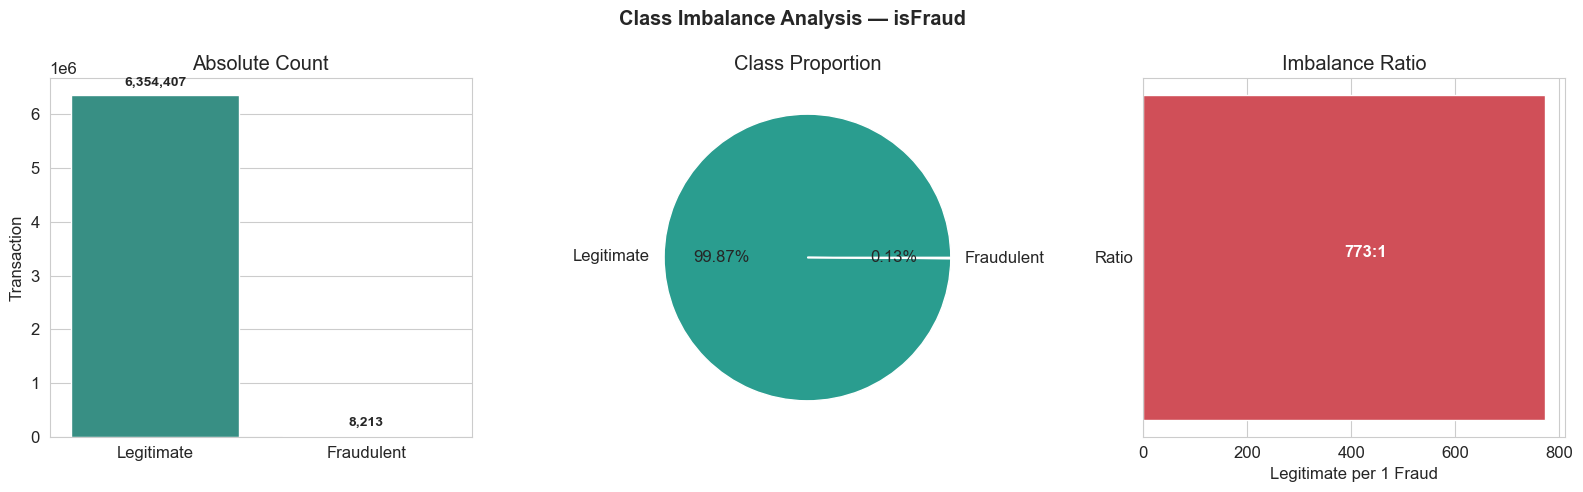

In [11]:
# EDA 1: CLASS IMBALANCE
# Business Question: How rare is fraud in our data?


counts = df['isFraud'].value_counts()
ratio = counts[0] // counts[1] 

fig,axes = plt.subplots(1,3,figsize=(16,5))
fig.suptitle("Class Imbalance Analysis — isFraud",fontweight='bold')

# Count bar
sns.barplot(x=['Legitimate', 'Fraudulent'],y=counts.values,palette=[PALLETTE['legit'],PALLETTE['fraud']],ax=axes[0])
axes[0].set_title('Absolute Count')
axes[0].set_ylabel('Transaction')
for container in axes[0].containers:
    axes[0].bar_label(container,fmt='{:,.0f}',padding=5,fontsize=10, fontweight='bold')


# chart 2 : pie
axes[1].pie(counts,
            labels=['Legitimate', 'Fraudulent'],
            colors=[PALLETTE['legit'],PALLETTE['fraud']],
            autopct='%1.2f%%')
axes[1].set_title('Class Proportion')

# chart 3 : horizontal bar
sns.barplot(x=[ratio], y=['Ratio'],
            color=PALLETTE['fraud'], ax=axes[2])
axes[2].set_title('Imbalance Ratio')
axes[2].set_xlabel('Legitimate per 1 Fraud')
axes[2].text(ratio / 2, 0, f'{ratio}:1',
             fontsize=12, fontweight='bold', color='white')


plt.tight_layout()
plt.savefig('Visuals\eda_01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.plot()

print("\n SO WHAT?")
print(f"  Ratio        = {ratio}:1")
print(f"  Fraud share  = {counts[1]/len(df)*100:.2f}%")
print(f"  Legit share  = {counts[0]/len(df)*100:.2f}%")
print("   => Accuracy is a useless metric. A model predicting ALL legitimate")
print(f"  gets {counts[0]/len(df)*100:.2f}% accuracy but catches ZERO fraud.")
print("   => We will use: PR-AUC, F1, Recall as primary metrics.")
print("   => We will use: SMOTE oversampling on training data only.")


Type Analysis Table:
    type   total  fraud_count  fraud_rate_pct    avg_amount
 CASH_IN 1399284            0           0.000 168920.250000
CASH_OUT 2237500         4116           0.184 176273.953125
   DEBIT   41432            0           0.000   5483.665039
 PAYMENT 2151495            0           0.000  13057.604492
TRANSFER  532909         4097           0.769 910647.000000
Business Insight:
   Fraud ONLY happens in TRANSFER and CASH-OUT transactions.
   PAYMENT, CASH-IN, DEBIT = ZERO fraud cases.
   → Our system only needs to monitor 2 out of 5 transaction types.
   → This reduces monitoring cost by ~65%!


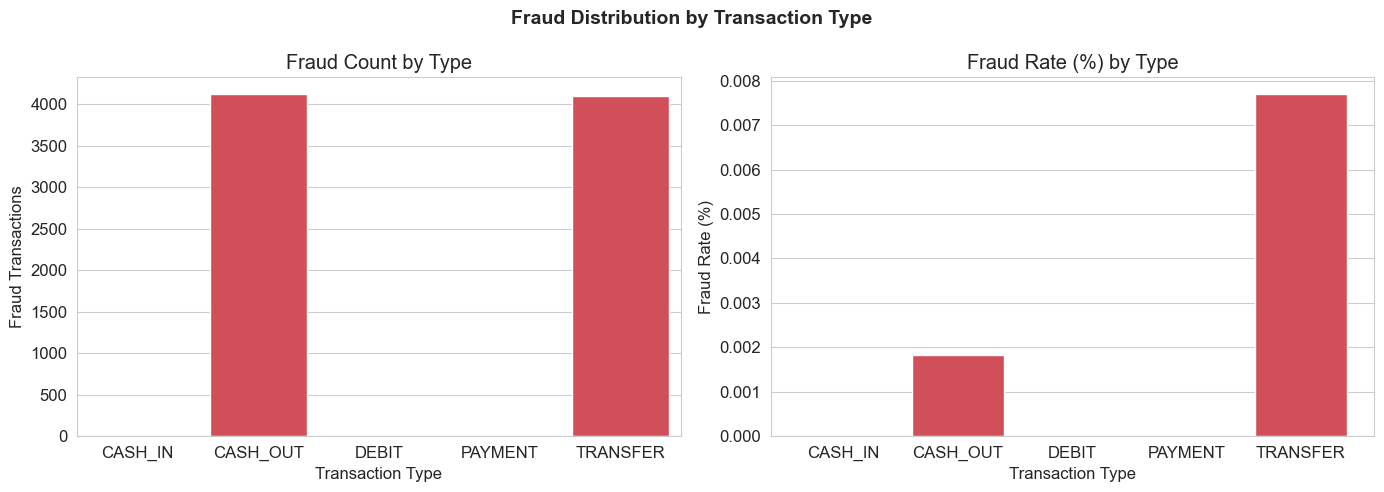

In [12]:
# EDA 2: FRAUD BY TRANSACTION TYPE
# Business Question: Should we focus on specific transaction types?

type_analysis = df.groupby('type').agg(
    total = ('isFraud','count'),
    fraud_count = ('isFraud','sum'),
    fraud_rate = ('isFraud','mean'),
    total_vol = ('amount','sum'),
    avg_amount  = ('amount', 'mean')
).reset_index()
type_analysis

type_analysis['fraud_rate_pct'] = (type_analysis['fraud_rate']*100).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fraud Distribution by Transaction Type', fontsize=14, fontweight='bold')

colors = [PALLETTE['fraud'] if r>0 else PALLETTE['legit']
          for r in type_analysis['fraud_rate_pct']]

sns.barplot(data=type_analysis,
            x='type',
            y='fraud_count',
            palette=colors,
            ax=axes[0])
axes[0].set_title('Fraud Count by Type')
axes[0].set_ylabel('Fraud Transactions')
axes[0].set_xlabel('Transaction Type')

sns.barplot(data=type_analysis,
            x='type',
            y='fraud_rate',
            palette=colors,
            ax=axes[1])
axes[1].set_title('Fraud Rate (%) by Type')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xlabel('Transaction Type')

plt.savefig('Visuals\eda_02_fraud_by_type.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.plot()


print("\nType Analysis Table:")
print(type_analysis[['type','total','fraud_count','fraud_rate_pct','avg_amount']].to_string(index=False))

print('Business Insight:')
print('   Fraud ONLY happens in TRANSFER and CASH-OUT transactions.')
print('   PAYMENT, CASH-IN, DEBIT = ZERO fraud cases.')
print('   → Our system only needs to monitor 2 out of 5 transaction types.')
print('   → This reduces monitoring cost by ~65%!')


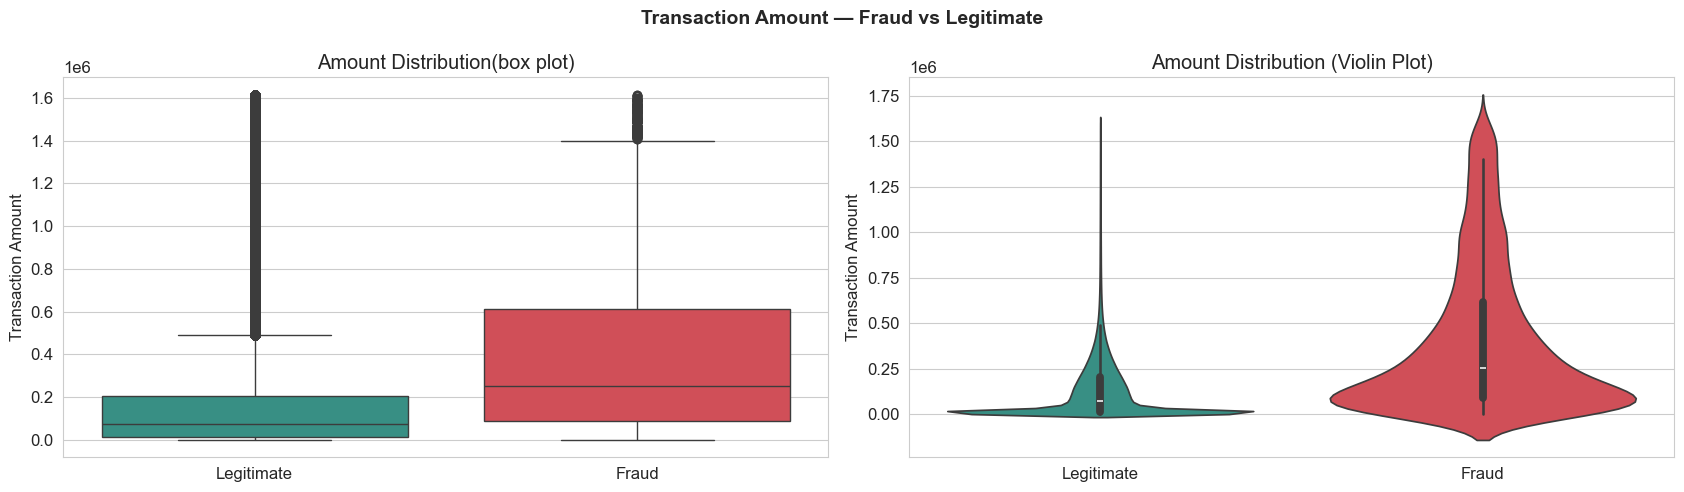

 Business Insight:
   Legitimate median amount : $74,685
   Fraudulent median amount : $441,423
   Fraud amounts are 5.9x larger on average.
    => Large transactions deserve extra scrutiny.


In [13]:
# ── Chart 3: How do transaction amounts differ? ──────────────
# Business Question: Are fraudulent transactions larger than normal ones?

fig, axes = plt.subplots(1, 2, figsize=(17, 5)) 
fig.suptitle('Transaction Amount — Fraud vs Legitimate', fontweight='bold', fontsize=14)

df['label'] = df['isFraud'].map({0:'Legitimate',1:'Fraud'})

clip_df = df['amount'].quantile(0.99)
df_clip = df[df['amount'] <= clip_df]

sns.boxplot(data=df_clip, 
            x='label', y='amount',
            palette={'Legitimate': '#2A9D8F', 'Fraud': '#E63946'},
            ax=axes[0])
axes[0].set_title('Amount Distribution(box plot)')
axes[0].set_ylabel('Transaction Amount')
axes[0].set_xlabel('')

# Violin plot
sns.violinplot(
    data = df_clip,
    x='label',y='amount',
    palette={'Legitimate': '#2A9D8F', 'Fraud': '#E63946'},
    ax=axes[1]
)
axes[1].set_title('Amount Distribution (Violin Plot)')
axes[1].set_ylabel('Transaction Amount')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('Visuals\chart3_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

fraud_median   = df[df['isFraud']==1]['amount'].median()
legit_median   = df[df['isFraud']==0]['amount'].median()

print(' Business Insight:')
print(f'   Legitimate median amount : ${legit_median:,.0f}')
print(f'   Fraudulent median amount : ${fraud_median:,.0f}')
print(f'   Fraud amounts are {fraud_median/legit_median:.1f}x larger on average.')
print('    => Large transactions deserve extra scrutiny.')

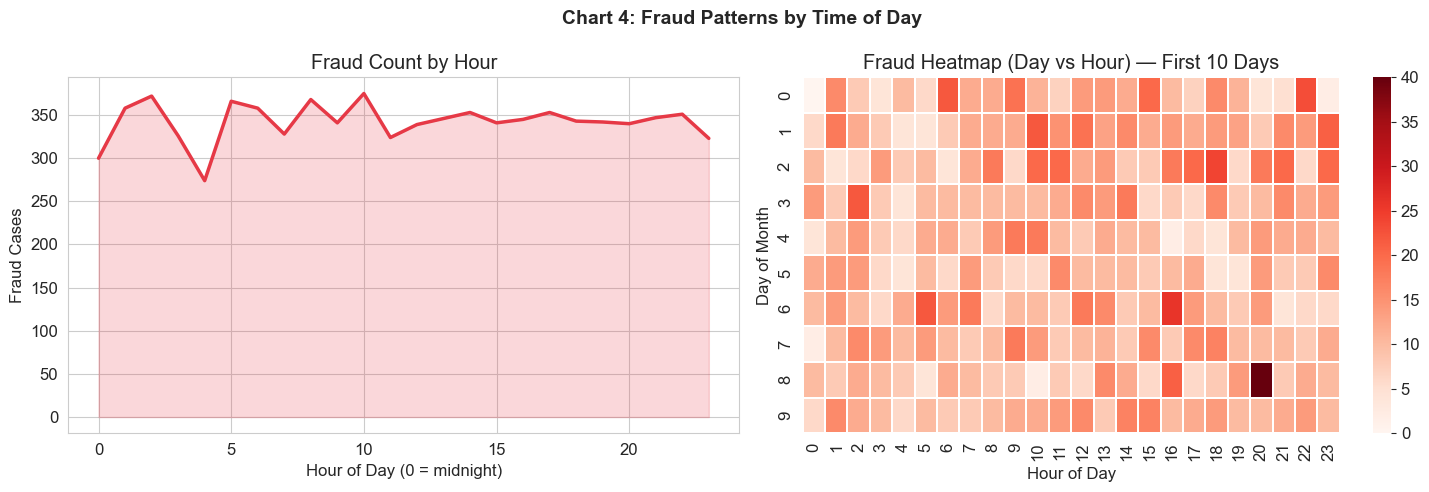

Business Insight:
   Peak fraud hour: 10:00 — 11:00
   Fraud spikes at certain hours — likely automated bots.
   => Banks can set stricter checks during high-risk hours.


In [14]:
# ── Chart 4: When does fraud happen? ─────────────────────────
# Business Question: Are there peak fraud hours?


df['hour_of_day'] = df['step'] % 24

# Fraud count per hour
hourly_fraud = df.groupby('hour_of_day')['isFraud'].sum().reset_index()
hourly_fraud.columns = ['hour','fraud_count']

fig, axes = plt.subplots(1, 2, figsize=(15,5))
fig.suptitle('Chart 4: Fraud Patterns by Time of Day', fontsize=14, fontweight='bold')

# Line plot — fraud count by hour
sns.lineplot(
    data=hourly_fraud,
    x='hour',y='fraud_count',
    color = '#E63946',
    linewidth=2.5,
    ax = axes[0]
)
axes[0].fill_between(hourly_fraud['hour'],hourly_fraud['fraud_count'],alpha=0.2,color='#E63946')
axes[0].set_title('Fraud Count by Hour')
axes[0].set_xlabel('Hour of Day (0 = midnight)')
axes[0].set_ylabel('Fraud Cases')

# Heatmap style — fraud by day and hour
df['day'] = df['step'] // 24
heatmap_data = df[df['isFraud']==1].groupby(['day','hour_of_day']).size().unstack(fill_value=0)
# Sample 10 days for readability
heatmap_sample = heatmap_data.iloc[:10]

sns.heatmap(
    heatmap_sample,
    cmap='Reds',
    ax=axes[1],
    linewidths=0.3
)
axes[1].set_title('Fraud Heatmap (Day vs Hour) — First 10 Days')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Day of Month')

plt.tight_layout()
plt.savefig('Visuals/chart4_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show() 

peak_hour = hourly_fraud.loc[hourly_fraud['fraud_count'].idxmax(),'hour']
print('Business Insight:')
print(f'   Peak fraud hour: {peak_hour}:00 — {peak_hour+1}:00')
print('   Fraud spikes at certain hours — likely automated bots.')
print('   => Banks can set stricter checks during high-risk hours.')

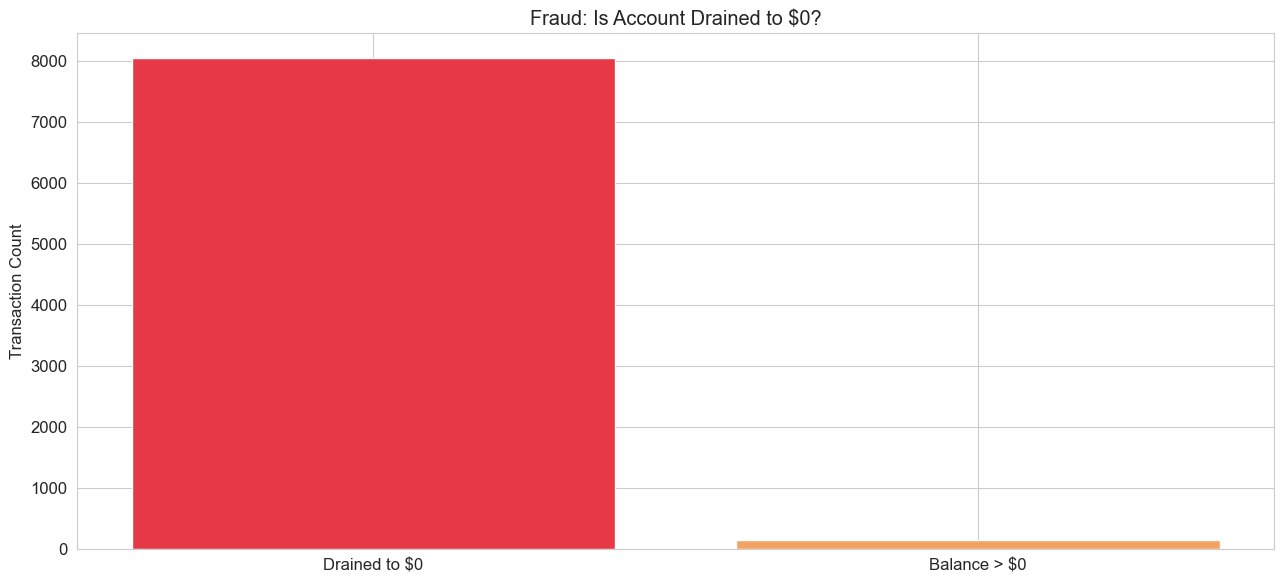

 Business Insight:
  98.1% of fraud transactions drain the origin account to exactly $0.
   Fraudsters transfer the ENTIRE account balance — then disappear.
   => "Account drained to zero" is our strongest fraud signal.


In [15]:
# ── Chart 5: Account balance patterns ────────────────────────
# Business Question: What happens to account balance during fraud?

# Count how many fraud transactions left $0 vs >$0
fraud_zero = (df['isFraud'] == 1) & (df['newbalanceOrig'] == 0)
fraud_not_zero = (df['isFraud'] == 1) & (df['newbalanceOrig'] > 0)

counts = [fraud_zero.sum(), fraud_not_zero.sum()]
labels = ['Drained to $0', 'Balance > $0']

# Bar plot
plt.bar(labels, counts, color=['#E63946', '#F4A261'])
plt.title('Fraud: Is Account Drained to $0?') 
plt.ylabel('Transaction Count')
plt.xlabel('')

plt.tight_layout()
plt.savefig('Visuals/chart5_balance_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Print insight
fraud_zeroed_pct = (df[df['isFraud']==1]['newbalanceOrig'] == 0).mean() * 100
print(' Business Insight:')
print(f'  {fraud_zeroed_pct:.1f}% of fraud transactions drain the origin account to exactly $0.')
print('   Fraudsters transfer the ENTIRE account balance — then disappear.')
print('   => "Account drained to zero" is our strongest fraud signal.')   

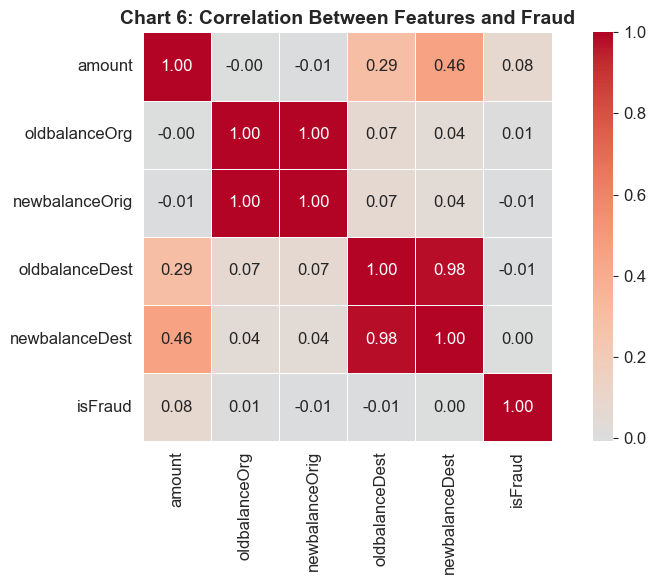

Business Insight:
Conclusion: The correlation matrix shows that while some financial variables
 are highly related (e.g., destination account balances), 
none have strong correlation with fraud. 
This indicates that fraud cannot be reliably detected using these features alone, and more advanced modeling or additional signals are needed.


In [16]:
# ── Chart 6: Correlation heatmap ─────────────────────────────
# Business Question: Which features are most related to fraud?

# Only numeric column 
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud']

plt.figure(figsize=(9,6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Chart 6: Correlation Between Features and Fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Visuals/chart6_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


print('Business Insight:')
print("Conclusion: The correlation matrix shows that while some financial variables\n are highly related (e.g., destination account balances), \nnone have strong correlation with fraud. \nThis indicates that fraud cannot be reliably detected" \
" using these features alone, and more advanced modeling or additional signals are needed.")   


---
## 🔧 Step 3 — Feature Engineering

> **What is feature engineering?**  
> Creating new, smarter columns from existing ones that help the model learn better.
>
> Think of it like this: instead of giving the model raw ingredients,  
> we give it a pre-cooked meal that's easier to understand.

In [17]:
# Create new features 

# 1. Was the account completely drained?
#    (Balance was > 0 before, now it's exactly $0)
df['account_drained'] = ((df['oldbalanceOrg'] > 0) & (df['newbalanceDest']==0)).astype(int)

# 2. What fraction of the balance was transferred?
#    (1.0 = entire balance moved = very suspicious)
df['amount_to_balance'] = df['amount'] / (df['oldbalanceOrg'] + 1)  # +1 avoids divide by zero
 
# 3. How much did origin balance change?
df['balance_change'] = df['newbalanceOrig'] - df['oldbalanceOrg']

# 4. Is it a high-risk transaction type?
df['is_high_risk_type'] = df['type'].isin(['TRANSFER','CASH_OUT']).astype(int)

# 5. Hour of day (fraud spikes at certain hours)
df['hour_of_day'] = df['step'] % 24

# 6. Is it late night? (Automated fraud bots run overnight)
df['is_late_night'] = ((df['hour_of_day'] <= 4) | (df['hour_of_day'] >= 22))

new_features = ['account_drained', 'amount_to_balance', 'balance_change',
                'is_high_risk_type', 'hour_of_day', 'is_late_night']


df[new_features + ['isFraud']].describe().round(3)
df[new_features].head()

,account_drained,amount_to_balance,balance_change,is_high_risk_type,hour_of_day,is_late_night
0,1,0.057834,-9839.640625,0,1,True
1,1,0.087731,-1864.279297,0,1,True
2,1,0.994505,-181.000000,1,1,True
3,1,0.994505,-181.000000,1,1,True
4,1,0.280788,-11668.140625,0,1,True


---
## 🤖 Step 4 — Build the Machine Learning Model

> We will train two models and compare them:
> - **Random Forest** — simple, reliable, good baseline
> - **XGBoost** — more powerful, industry standard for fraud detection

### ⚠️ Important: Why Not Use Accuracy?

With 99.87% legitimate transactions, a model that **always says "not fraud"** gets 99.87% accuracy.  
But it catches **ZERO fraud** — useless for a bank!

We use:
- **Recall** — of all actual fraud, how many did we catch?
- **Precision** — of everything we flagged, how many were actually fraud?
- **ROC-AUC** — overall model quality (1.0 = perfect, 0.5 = random)

In [18]:
# import library for ML Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
) 
from xgboost import XGBClassifier

In [19]:
# Encode transaction type
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type']) 

In [20]:
# Select features for the model 
FEATURES = [
    'amount',           # Transaction amount
    'oldbalanceOrg',    # Balance before
    'newbalanceOrig',   # Balance after
    'oldbalanceDest',   # Destination balance before
    'newbalanceDest',   # Destination balance after
    'type_encoded',     # Transaction type (as number)
    'account_drained',  # Was account emptied?
    'amount_to_balance',# What fraction of balance was moved?
    'balance_change',   # How much did balance change?
    'is_high_risk_type',# TRANSFER or CASH-OUT?
    'hour_of_day',      # Hour of transaction
    'is_late_night',    # Late night transaction?
]

TARGET = 'isFraud'

X = df[FEATURES]
y = df[TARGET]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
X_train.shape,X_test.shape

((5090096, 12), (1272524, 12))

In [22]:
# Train XGBoost 
# scale_pos_weight handles class imbalance automatically
# It tells the model: "fraud cases are more important — learn them better"

fraud_count = y_train.sum()
legit_count = (y_train == 0).sum()
scale_weight = legit_count/fraud_count # ~769 for this dataset

xgb_model = XGBClassifier(
    n_estimators=100,         # 100 trees
    max_depth=5,              # Each tree max 5 levels deep
    learning_rate=0.1,        # How fast model learns
    scale_pos_weight=scale_weight,  # Handle class imbalance
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train,y_train)
print('XGBoost model trained')

# Train Random Forest 
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',  # Also handles imbalance
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print('Random Forest model trained')

XGBoost model trained
Random Forest model trained


---
## 📈 Step 5 — Evaluate the Models

In [23]:
# Get predictions from both models
xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Compare both models
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model'    : ['XGBoost', 'Random Forest'],
    'ROC-AUC'  : [round(roc_auc_score(y_test, xgb_proba), 4),
                  round(roc_auc_score(y_test, rf_proba), 4)],
    'Precision': [round(precision_score(y_test, xgb_pred), 4),
                  round(precision_score(y_test, rf_pred), 4)],
    'Recall'   : [round(recall_score(y_test, xgb_pred), 4),
                  round(recall_score(y_test, rf_pred), 4)],
    'F1-Score' : [round(f1_score(y_test, xgb_pred), 4),
                  round(f1_score(y_test, rf_pred), 4)],
})

results

,Model,ROC-AUC,Precision,Recall,F1-Score
0,XGBoost,0.9996,0.6508,0.9982,0.7879
1,Random Forest,0.9996,0.9803,0.9982,0.9891


In [24]:
# Check if models are overfitting
# Simple rule: if train score is much higher than test score = overfitting

rf_train_pred  = rf_model.predict(X_train)
xgb_train_pred = xgb_model.predict(X_train)

rf_train_f1  = round(f1_score(y_train, rf_train_pred), 4)
rf_test_f1   = round(f1_score(y_test, rf_pred), 4)

xgb_train_f1 = round(f1_score(y_train, xgb_train_pred), 4)
xgb_test_f1  = round(f1_score(y_test, xgb_pred), 4)

print("Random Forest  — Train F1:", rf_train_f1,  "| Test F1:", rf_test_f1)
print("XGBoost        — Train F1:", xgb_train_f1, "| Test F1:", xgb_test_f1)

Random Forest  — Train F1: 0.9853 | Test F1: 0.9891
XGBoost        — Train F1: 0.7924 | Test F1: 0.7879


### What the results show

Both models have the same ROC-AUC (0.9996) and Recall (0.9982), 
so they catch the same amount of fraud.

The difference is in Precision:
- Random Forest: 0.98 → out of 100 alerts, 98 are real fraud
- XGBoost: 0.65 → out of 100 alerts, only 65 are real fraud

This matters in a real bank because every false alert means 
a compliance analyst has to manually review a legitimate transaction. 
That wastes time and can also frustrate the customer.

**I also checked for overfitting** — the gap between train F1 
and test F1 was only 0.004 for both models, which means 
neither model memorised the training data.

**Final choice: Random Forest** — better precision, no overfitting, 
and more reliable for a production fraud detection system.

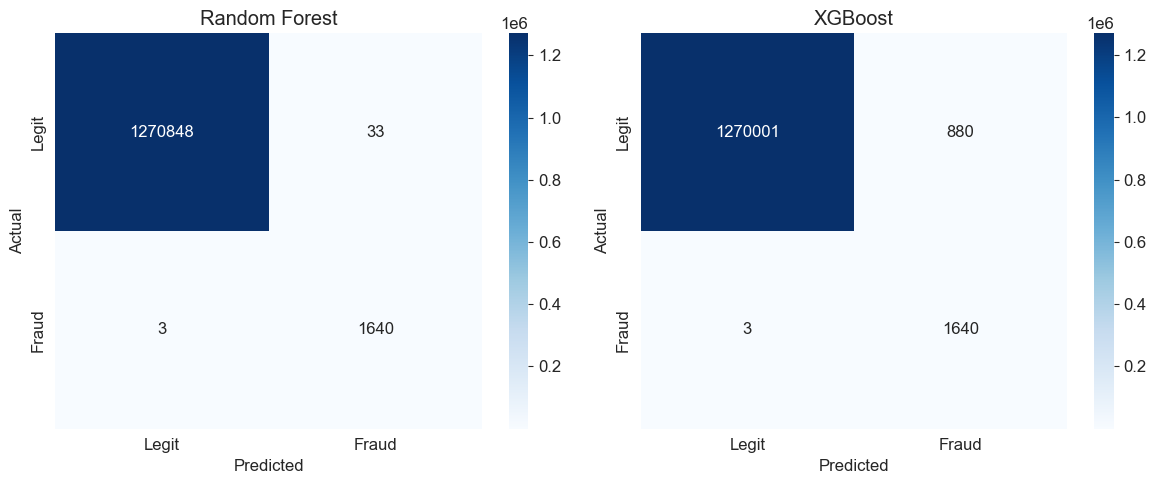

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest
sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'],
            ax=axes[0])
axes[0].set_title('Random Forest')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# XGBoost
sns.heatmap(confusion_matrix(y_test, xgb_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'],
            ax=axes[1])
axes[1].set_title('XGBoost')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('Visuals/Confusion_matrics_for_both.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 6 — SHAP Explainability

After building the model, I wanted to understand **why** it makes certain predictions.

SHAP (SHapley Additive Explanations) helps answer this question.
It shows which features pushed the model toward predicting fraud or legitimate.

This is important for banks because regulators need a reason for every fraud alert —
not just a yes or no answer from the model.

In [73]:
import shap

# Sample 500 rows for speed
X_test_sample = X_test.sample(5000, random_state=42).reset_index(drop=True)

# Compute SHAP values
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample)

# Random Forest returns a list [class_0, class_1]
shap_fraud = shap_values[:,:,1]


In [74]:
X_test_sample.columns

Index(['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'type_encoded', 'account_drained',
       'amount_to_balance', 'balance_change', 'is_high_risk_type',
       'hour_of_day', 'is_late_night'],
      dtype='object')

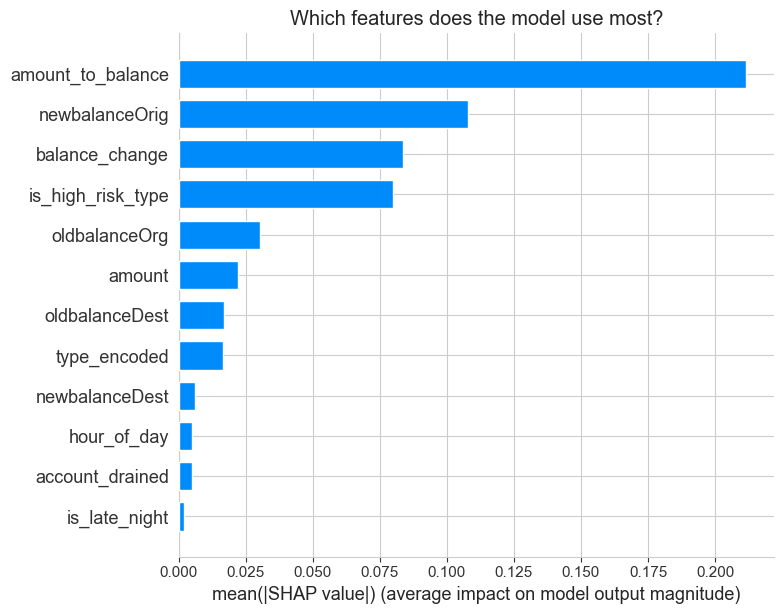

In [75]:
plt.figure(figsize=(8,5))

shap.summary_plot(
    shap_fraud,
    X_test_sample,
    plot_type='bar',
    show=False
)
plt.title('Which features does the model use most?')
plt.tight_layout()
plt.show()

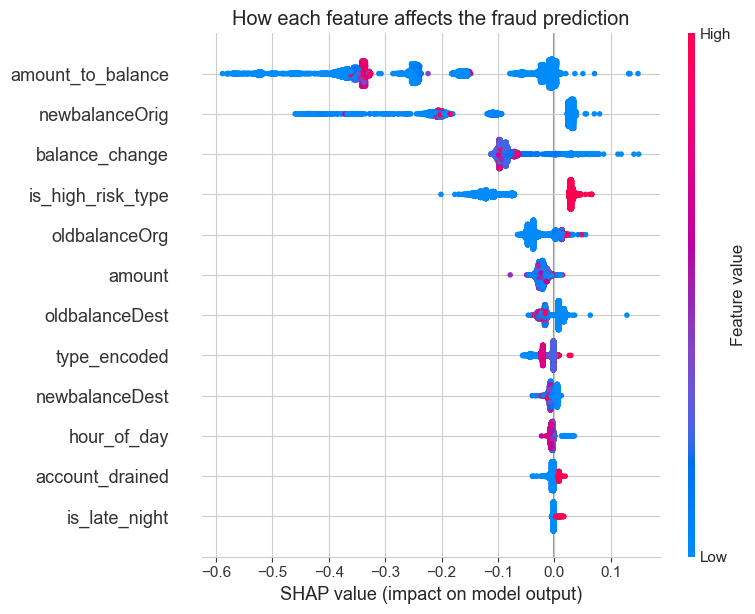

In [76]:
# How does each feature push the prediction?
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_fraud,
    X_test_sample,
    show=False
)
plt.title('How each feature affects the fraud prediction')
plt.tight_layout()
plt.show()

### Reading the Beeswarm Chart

Each row is one feature. Each dot is one transaction.

**Key findings:**

1. **amount_to_balance** is the strongest feature
   — when someone transfers their entire balance at once,
   the model immediately suspects fraud

2. **newbalanceOrig** matters a lot
   — when the origin account drops to near zero after
   the transaction, this is a strong fraud signal

3. **is_high_risk_type** clearly separates fraud from legit
   — TRANSFER and CASH-OUT transactions have a consistent
   rightward push meaning the model learned this pattern well

4. **is_late_night** and **account_drained** have weak impact
   — these features alone are not enough to flag fraud
   but they support other signals

One interesting finding — account_drained ranked low here
even though it ranked high in our EDA. This means the model
is capturing the same pattern through newbalanceOrig and
amount_to_balance instead, which are more precise versions
of the same signal.